# Chapter 8 - Feature Importance

## Preparation

In [ ]:
import os
import sys
sys.path.append(os.path.abspath(os.path.join('..')))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification
from sklearn.decomposition import PCA

from utils.sampling_bars import dollar_bar
from utils.feature_importance import feature_importance, plot_feature_importance, run_test

%matplotlib inline
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = 16,6

data_path = '../data/processed/clean_IVE_tickbidask.parq'
df = pd.read_parquet(data_path)

dollar_bars = dollar_bar(df)

## 1. Using the code presented in Section 8.6:

### a. Generate a dataset (X, y).

In [2]:
def get_test_data(n_features=40, n_informative=10, n_redundant=10, n_samples=10000):
    # generate a random dataset for a classification problem    
    trains_df, labels_df = make_classification(
        n_samples=n_samples, 
        n_features=n_features, 
        n_informative=n_informative, 
        n_redundant=n_redundant, 
        random_state=0, 
        shuffle=False
    )
    # Create a DatetimeIndex using start and periods (not end)
    indices = pd.date_range(
        start=pd.Timestamp.today(), 
        periods=n_samples, 
        freq=pd.tseries.offsets.Minute()
    )
    trains_df = pd.DataFrame(trains_df, index=indices)
    labels_df = pd.Series(labels_df, index=indices).to_frame('bin')
    
    columns = ['I_%s' % i for i in range(n_informative)] + ['R_%s' % i for i in range(n_redundant)]
    columns += ['N_%s' % i for i in range(n_features - len(columns))]
    trains_df.columns = columns

    labels_df['w'] = 1.0 / labels_df.shape[0]
    labels_df['t1'] = pd.Series(labels_df.index, index=labels_df.index)
    return trains_df, labels_df

In [3]:
trains_df, labels_df = get_test_data(n_samples=5000)

In [4]:
print("Train: ")
trains_df.head()

Train: 


,I_0,I_1,I_2,I_3,I_4,I_5,I_6,I_7,I_8,I_9,...,N_10,N_11,N_12,N_13,N_14,N_15,N_16,N_17,N_18,N_19
2026-05-25 15:50:25.674838,1.290266,-2.040667,-1.873027,-0.789607,0.414355,0.667886,1.050360,1.747905,-2.914470,-0.405006,...,0.405365,-0.378820,0.032483,0.339937,2.422134,0.567746,1.544970,1.018770,1.105146,-0.078799
2026-05-25 15:51:25.674838,-2.021959,-1.964300,1.296527,-3.859338,1.766699,-2.228100,-0.835588,3.198388,-3.975147,-2.518164,...,1.144642,0.131779,0.488892,0.758017,1.582577,-0.454677,-0.460030,-0.237855,-0.057687,0.900714
2026-05-25 15:52:25.674838,3.601406,2.604456,-0.624733,0.118112,0.660409,1.610909,-0.206490,1.521404,-1.500562,-2.610983,...,0.096948,-0.440846,-0.431668,0.575823,-0.776558,-0.313590,0.164424,-0.946697,2.484171,-0.130001
2026-05-25 15:53:25.674838,1.372715,0.016580,1.808073,-3.830279,1.564528,-1.048479,-2.912019,2.376320,0.350093,-2.465828,...,0.847725,1.005726,0.833709,-0.409758,-0.489561,-0.688357,1.089211,-0.043152,-0.640553,0.692347
2026-05-25 15:54:25.674838,0.831379,-1.741836,-0.960628,-0.331190,1.967134,0.902421,0.500571,-0.561081,-2.158016,-0.477999,...,1.179118,0.561721,-0.272975,0.442190,1.961846,0.108216,-1.020289,0.606157,-0.933744,-0.693793


In [5]:
print("Label: ")
labels_df.head()

Label: 


,bin,w,t1
2026-05-25 15:50:25.674838,0,0.0002,2026-05-25 15:50:25.674838
2026-05-25 15:51:25.674838,0,0.0002,2026-05-25 15:51:25.674838
2026-05-25 15:52:25.674838,0,0.0002,2026-05-25 15:52:25.674838
2026-05-25 15:53:25.674838,0,0.0002,2026-05-25 15:53:25.674838
2026-05-25 15:54:25.674838,0,0.0002,2026-05-25 15:54:25.674838


In [6]:
labels_df["bin"].value_counts()

bin
1    2504
0    2496
Name: count, dtype: int64

### b. Apply a PCA transformation on X, which we denote $\dot{X}$.

In [7]:
def get_e_vec(dot, var_thres):
    # compute e_vec from dot prod matrix, reduce dimension
    e_val, e_vec = np.linalg.eigh(dot)
    idx = e_val.argsort()[::-1]  # arguments for sorting e_val desc
    e_val, e_vec = e_val[idx], e_vec[:, idx]
    # 2) only positive e_vals
    e_val = pd.Series(e_val, index=['PC_' + str(i + 1) for i in range(e_val.shape[0])])
    e_vec = pd.DataFrame(e_vec, index=dot.index, columns=e_val.index)
    e_vec = e_vec.loc[:, e_val.index]
    # 3) reduce dimension, form PCs
    cum_var = e_val.cumsum() / e_val.sum()
    dim = cum_var.values.searchsorted(var_thres)
    e_val, e_vec = e_val.iloc[:dim + 1], e_vec.iloc[:, :dim + 1]
    return e_val, e_vec

# -----------------------------------------------------------------------

def get_ortho_feats(df_x, var_thres=0.95):
    # Given a dataframe df_x of features, compute orthofeatures df_p
    df_z = df_x.sub(df_x.mean(), axis=1).div(df_x.std(), axis=1)  # standardize
    # df_z = df_x.sub(df_x.mean(), axis=1)
    dot = pd.DataFrame(np.dot(df_z.T, df_z), index=df_x.columns, columns=df_x.columns)
    e_val, e_vec = get_e_vec(dot, var_thres)
    df_p = np.dot(df_z, e_vec)
    return df_p

In [8]:
k = 9
pca = PCA(n_components=k)
X_pca = pca.fit_transform(trains_df)

X_pca

array([[  2.42924158,  -5.08958651,   6.09267476, ...,  -0.99199112,
          0.56460144,  -1.51401305],
       [  7.92899592,  -0.45500479,   7.77888715, ...,   0.37813871,
          1.76343438,  -0.52555658],
       [  6.60069245, -10.57254427,  -4.48619695, ...,  -2.48902467,
          0.68292035,   0.70597279],
       ...,
       [  6.51566791,   5.62401507,   5.42979245, ...,  -0.59872737,
          2.36289431,  -0.47990448],
       [ -4.51533056,  -0.68073986,  -4.58218072, ...,  -2.09306383,
         -3.19414916,  -2.42671489],
       [ 11.98717599,  -6.67802512,   6.42986515, ...,  -2.10314841,
          4.18566115,  -0.61610251]], shape=(5000, 9))

In [9]:
X_pca.shape

(5000, 9)

In [10]:
arr_p = get_ortho_feats(trains_df, var_thres=0.6)

df_p = pd.DataFrame(arr_p, index=trains_df.index, columns=["PC_" + str(i + 1) for i in range(arr_p.shape[1])])

df_p

,PC_1,PC_2,PC_3,PC_4,PC_5,PC_6,PC_7,PC_8,PC_9,PC_10,PC_11,PC_12,PC_13
2026-05-25 15:50:25.674838,-1.144901,1.421472,-1.605677,1.730367,-0.292844,0.964909,-0.130425,1.357116,-0.018477,0.246707,-1.202389,0.437973,0.311683
2026-05-25 15:51:25.674838,-2.448418,-0.335439,-1.481544,3.673679,-0.747162,-2.364278,-0.631413,0.177160,-0.891301,0.595626,-1.577660,0.283544,1.007292
2026-05-25 15:52:25.674838,-2.920477,3.253157,1.638767,-0.793370,-1.149272,1.297567,0.207714,0.753270,-0.892182,-0.456786,0.423477,1.368402,1.249996
2026-05-25 15:53:25.674838,-0.045108,-0.062310,2.834620,1.557105,-0.770797,-1.862123,-1.890725,-0.821357,0.888243,0.548339,0.598037,0.808681,0.199200
2026-05-25 15:54:25.674838,-0.473031,1.315040,-0.981793,0.086554,0.748891,-0.019639,-2.248573,-0.458696,-1.268408,0.751673,-1.679608,0.591696,0.707650
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-05-29 03:05:25.674838,-0.739571,-2.030133,0.860962,-0.004251,-0.081741,-0.059446,0.630865,-1.288000,0.547430,-0.002696,-2.244144,-0.156901,1.246855
2026-05-29 03:06:25.674838,0.069714,-0.600671,-3.135636,-1.155916,0.740103,-1.123160,-0.018964,0.184842,-0.122408,0.268263,-0.138049,-1.645938,-0.240597
2026-05-29 03:07:25.674838,-1.535447,-2.496526,-2.624792,-1.528167,0.947874,-0.946241,-0.630670,-0.712687,-1.789033,-0.620746,0.879576,-0.470071,-0.486396
2026-05-29 03:08:25.674838,1.484705,0.425766,0.510803,-2.991770,-1.564151,-1.162001,-1.331620,-0.197682,-2.109615,0.065667,0.382784,0.767956,0.864229


In [11]:
df_p.shape

(5000, 13)

### c. Compute MDI, MDA, and SFI feature importance on ($\dot{X}$, $y$), where the  base estimator is RF.

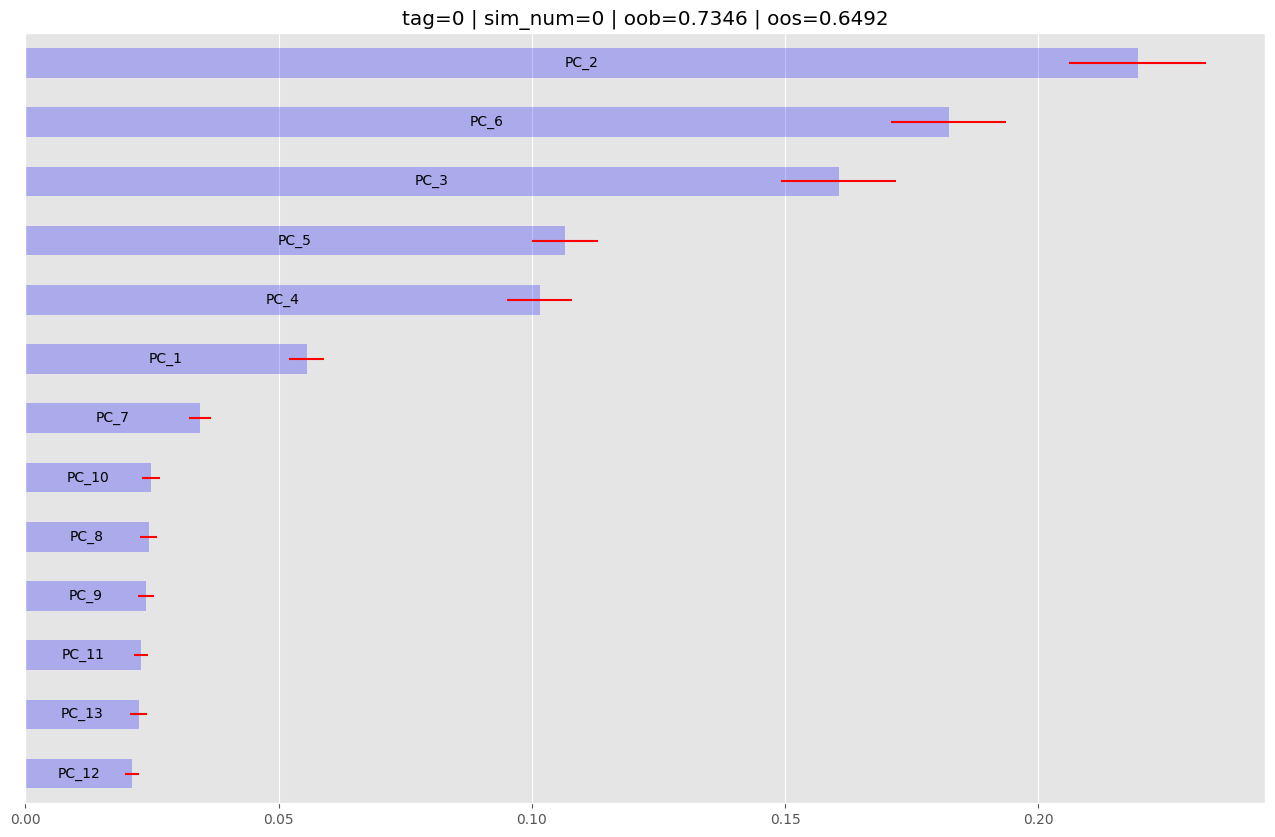

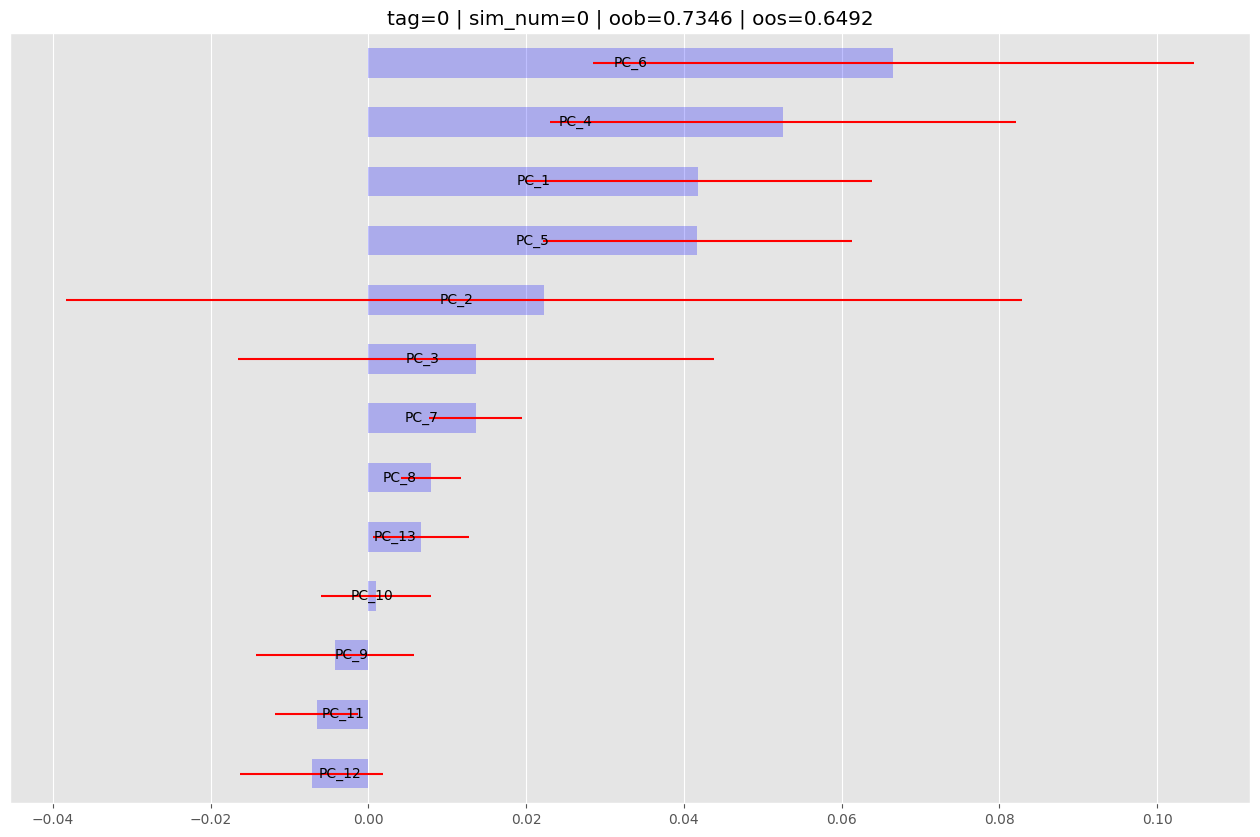

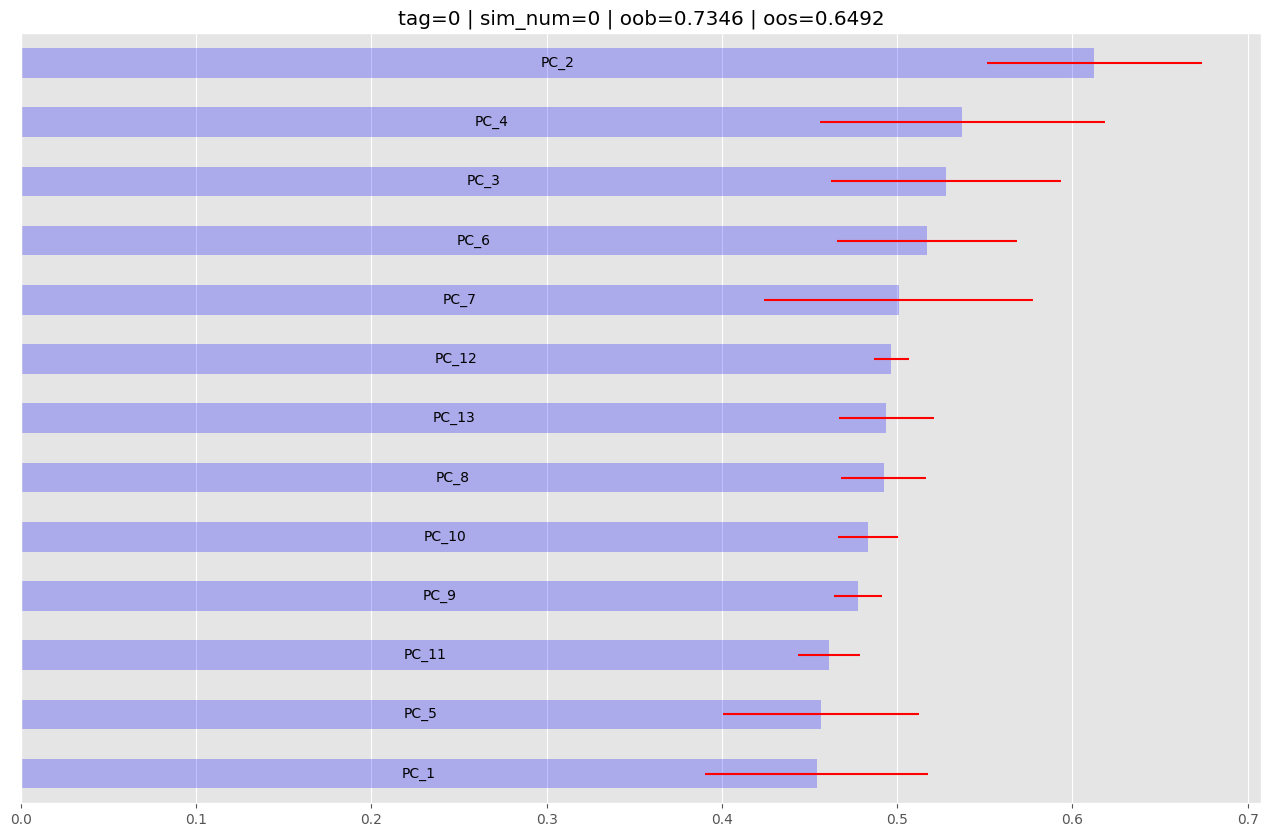

In [12]:
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=5,
    random_state=42,
    class_weight="balanced_subsample",
    n_jobs=-1,
    oob_score=True,
    max_features=int(1) # masking effects
)

run_test(model, df_p, labels_df, cv_n_splits=10, run='', metrics=['MDI', 'MDA', 'SFI'])

### d. Do the three methods agree on what features are important? Why?

They do not agree on a single feature, while `PC_2` is ranked the highest in MDI and SFI. While `PC_1` explains the most variance structure in `X`, it maybe irrelevant to the class label. PCA is unsupervised, so it never looks at the label. A high-variance direction can be mostly irrelevant to the class label, while a lower-variance PC can align better with the decision boundary.

## 2. From exercise 1, generate a new dataset $\ddot{X}$, where $\ddot{X}$ is a feature union of $X$ and $\dot{X}$.

In [13]:
union_train_df = pd.concat([trains_df, df_p], axis=1)
union_train_df.head()

,I_0,I_1,I_2,I_3,I_4,I_5,I_6,I_7,I_8,I_9,...,PC_4,PC_5,PC_6,PC_7,PC_8,PC_9,PC_10,PC_11,PC_12,PC_13
2026-05-25 15:50:25.674838,1.290266,-2.040667,-1.873027,-0.789607,0.414355,0.667886,1.050360,1.747905,-2.914470,-0.405006,...,1.730367,-0.292844,0.964909,-0.130425,1.357116,-0.018477,0.246707,-1.202389,0.437973,0.311683
2026-05-25 15:51:25.674838,-2.021959,-1.964300,1.296527,-3.859338,1.766699,-2.228100,-0.835588,3.198388,-3.975147,-2.518164,...,3.673679,-0.747162,-2.364278,-0.631413,0.177160,-0.891301,0.595626,-1.577660,0.283544,1.007292
2026-05-25 15:52:25.674838,3.601406,2.604456,-0.624733,0.118112,0.660409,1.610909,-0.206490,1.521404,-1.500562,-2.610983,...,-0.793370,-1.149272,1.297567,0.207714,0.753270,-0.892182,-0.456786,0.423477,1.368402,1.249996
2026-05-25 15:53:25.674838,1.372715,0.016580,1.808073,-3.830279,1.564528,-1.048479,-2.912019,2.376320,0.350093,-2.465828,...,1.557105,-0.770797,-1.862123,-1.890725,-0.821357,0.888243,0.548339,0.598037,0.808681,0.199200
2026-05-25 15:54:25.674838,0.831379,-1.741836,-0.960628,-0.331190,1.967134,0.902421,0.500571,-0.561081,-2.158016,-0.477999,...,0.086554,0.748891,-0.019639,-2.248573,-0.458696,-1.268408,0.751673,-1.679608,0.591696,0.707650


### a. Compute MDI, MDA, and SFI feature importance on $\ddot{X}$, where the  base estimator is RF.

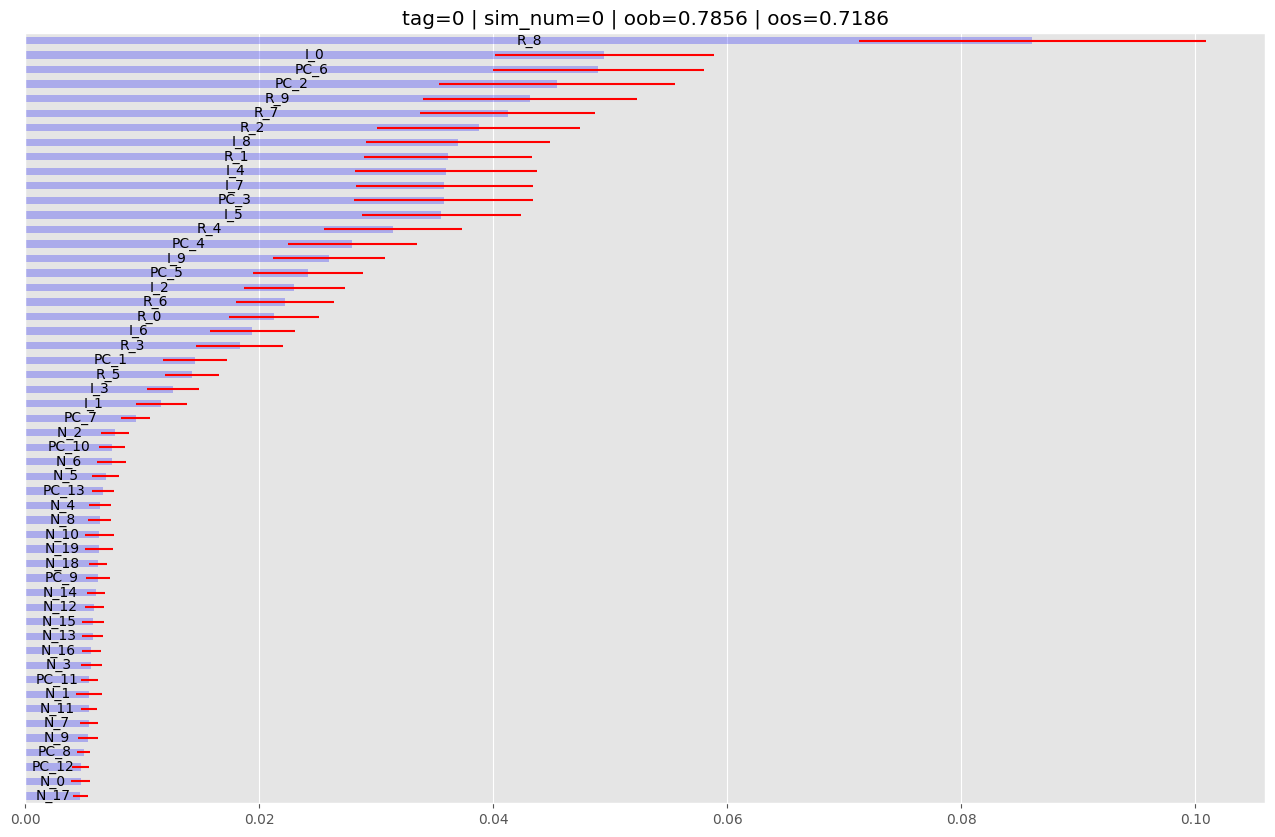

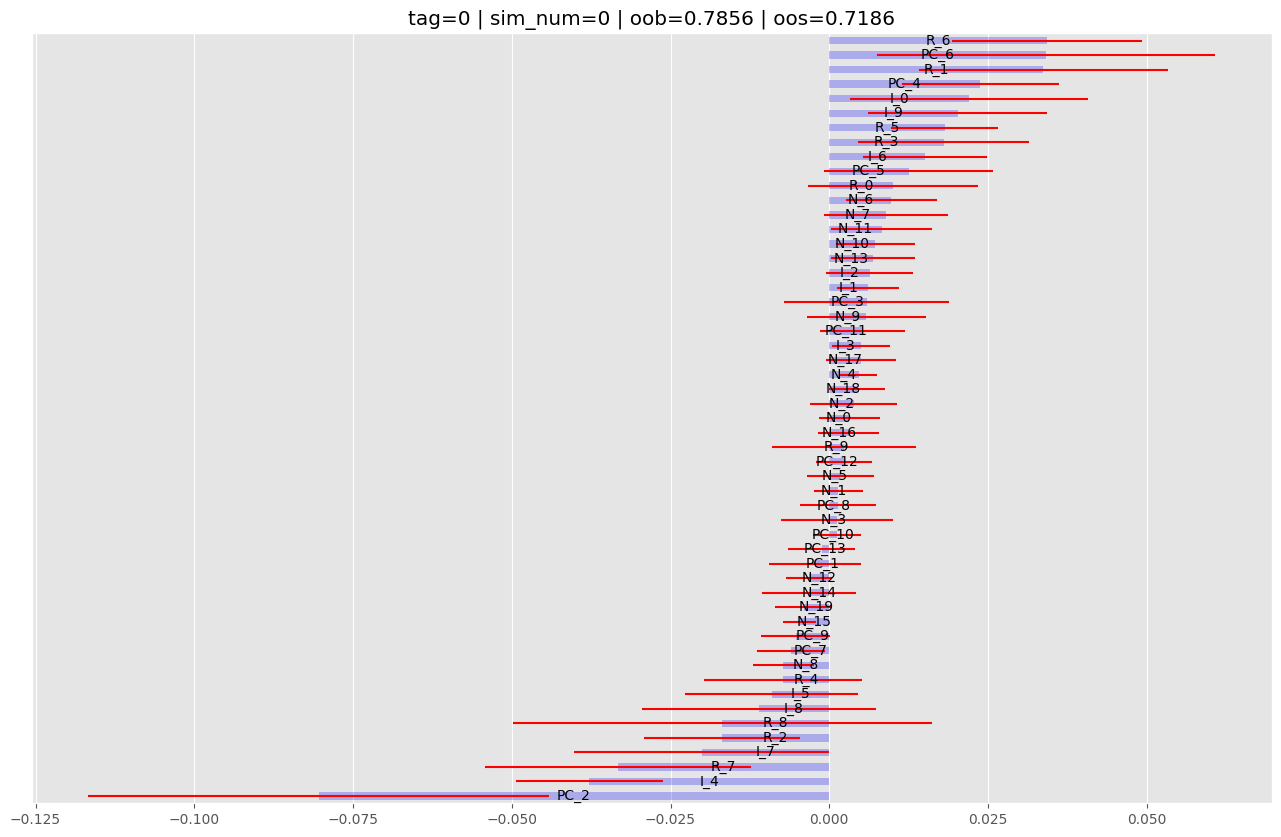

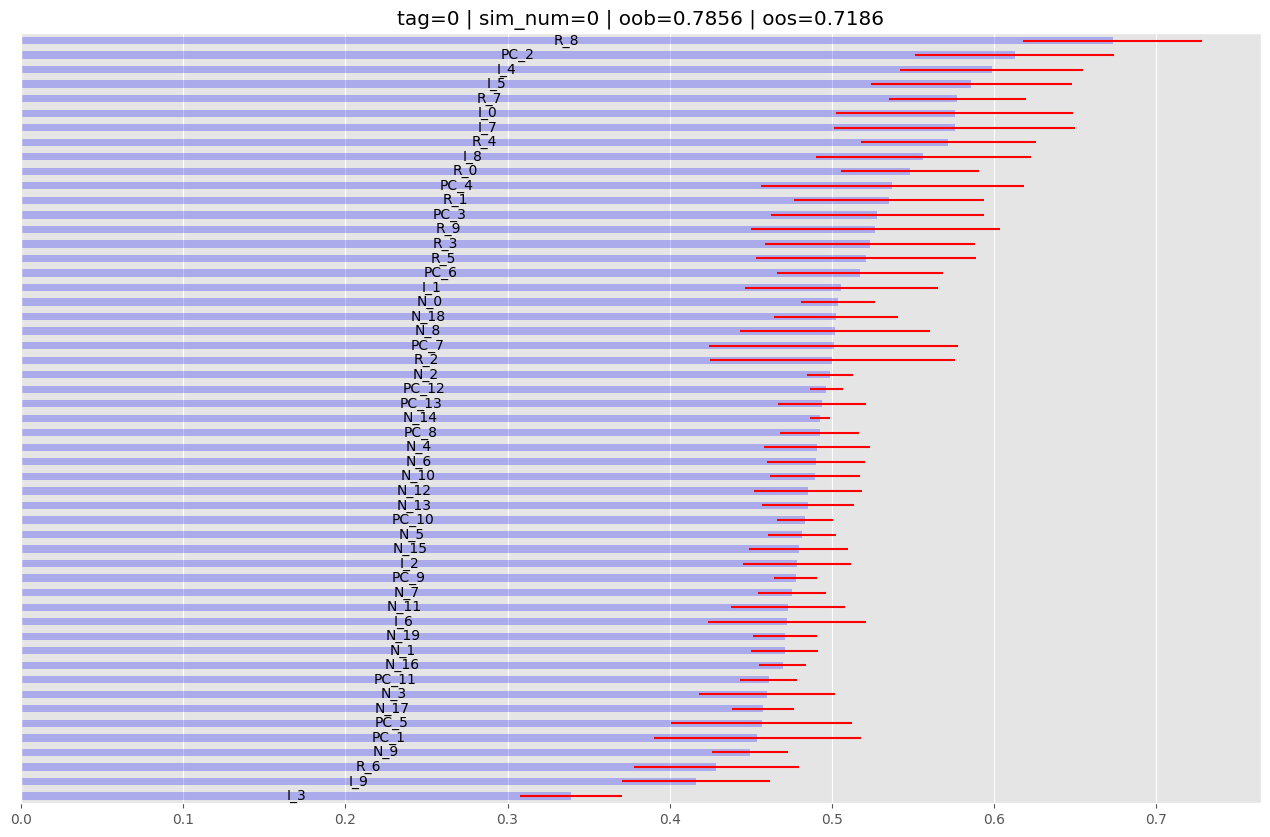

In [14]:
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=5,
    random_state=42,
    class_weight="balanced_subsample",
    n_jobs=-1,
    oob_score=True,
    max_features=int(1) # masking effects
)

run_test(model, union_train_df, labels_df, cv_n_splits=10, run='', metrics=['MDI', 'MDA', 'SFI'])

### b. Do the three methods agree on the important features? Why?

As same before, MDI and SFI all agree to the same feature, which is `R_8`, but MDA agree on `I_0`, which is an informative feature instead of a redundant feature. We trace the reason from the first principles:

* MDI rewards split usage inside the fitted forest.
* SFI rewards standalone predictive power.
* MDA rewards incremental importance conditional on all other features being present.

A redundant feature can win in MDI and SFT since the redundant feature may be a strong signal. A redundant feature can win here because it may combine several informative dimensions into one stronger marginal predictor. 

MDA, in contrast, asks “After training on all features, how much does out-of-sample accuracy drop if this one feature is destroyed?” Whle `R_8` may be a stronger marginal predictor, it is still redundant. Destroying it may not hurt much because the same information remains in `I_*` and `PC_*`.  If `R_6` is used by the fitted model in a way that is less replaceable, or its permutation causes more class flips, MDA can rank `R_6` highest.

## 3. Take the results from exercise 2:

### a. Drop the most important features according to each method, resulting in a features matrix $\dddot{X}$.

In [15]:
# Create the $\dddot{X}$
dropped_union_train_df = union_train_df.drop(columns=['R_8', 'I_0'])

dropped_union_train_df.head()

,I_1,I_2,I_3,I_4,I_5,I_6,I_7,I_8,I_9,R_0,...,PC_4,PC_5,PC_6,PC_7,PC_8,PC_9,PC_10,PC_11,PC_12,PC_13
2026-05-25 15:50:25.674838,-2.040667,-1.873027,-0.789607,0.414355,0.667886,1.050360,1.747905,-2.914470,-0.405006,2.218839,...,1.730367,-0.292844,0.964909,-0.130425,1.357116,-0.018477,0.246707,-1.202389,0.437973,0.311683
2026-05-25 15:51:25.674838,-1.964300,1.296527,-3.859338,1.766699,-2.228100,-0.835588,3.198388,-3.975147,-2.518164,7.128678,...,3.673679,-0.747162,-2.364278,-0.631413,0.177160,-0.891301,0.595626,-1.577660,0.283544,1.007292
2026-05-25 15:52:25.674838,2.604456,-0.624733,0.118112,0.660409,1.610909,-0.206490,1.521404,-1.500562,-2.610983,-5.730619,...,-0.793370,-1.149272,1.297567,0.207714,0.753270,-0.892182,-0.456786,0.423477,1.368402,1.249996
2026-05-25 15:53:25.674838,0.016580,1.808073,-3.830279,1.564528,-1.048479,-2.912019,2.376320,0.350093,-2.465828,1.421486,...,1.557105,-0.770797,-1.862123,-1.890725,-0.821357,0.888243,0.548339,0.598037,0.808681,0.199200
2026-05-25 15:54:25.674838,-1.741836,-0.960628,-0.331190,1.967134,0.902421,0.500571,-0.561081,-2.158016,-0.477999,2.421757,...,0.086554,0.748891,-0.019639,-2.248573,-0.458696,-1.268408,0.751673,-1.679608,0.591696,0.707650


### b. Compute MDI, MDA, and SFI feature importance on $\dddot{X}$, where the  base estimator is RF.

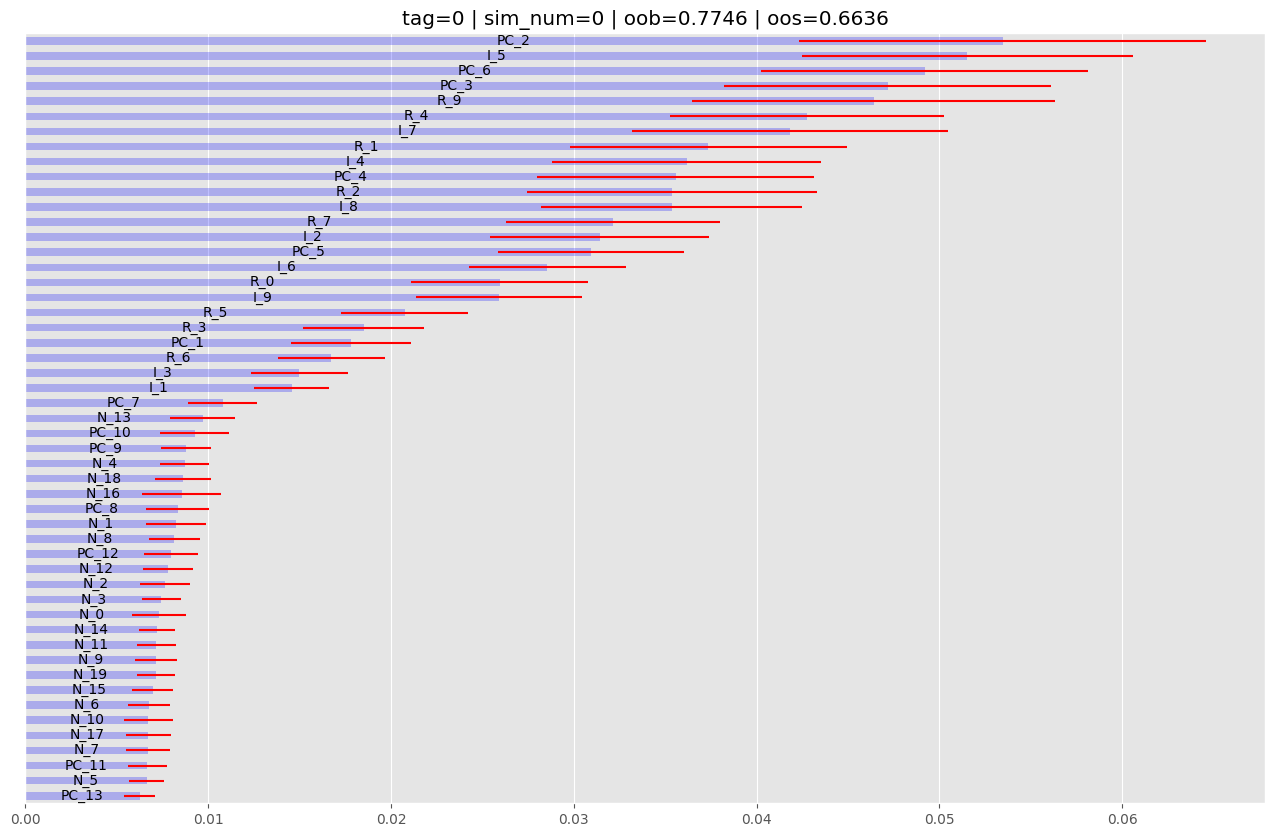

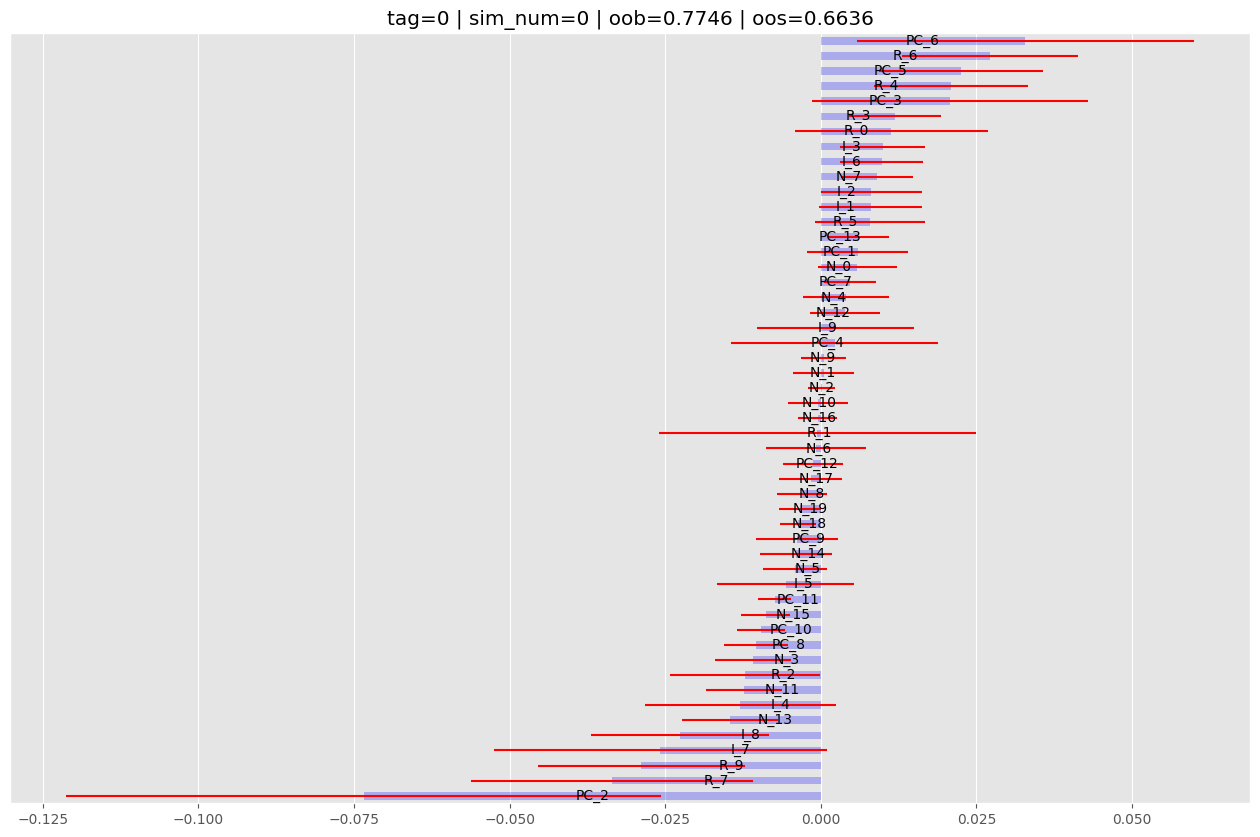

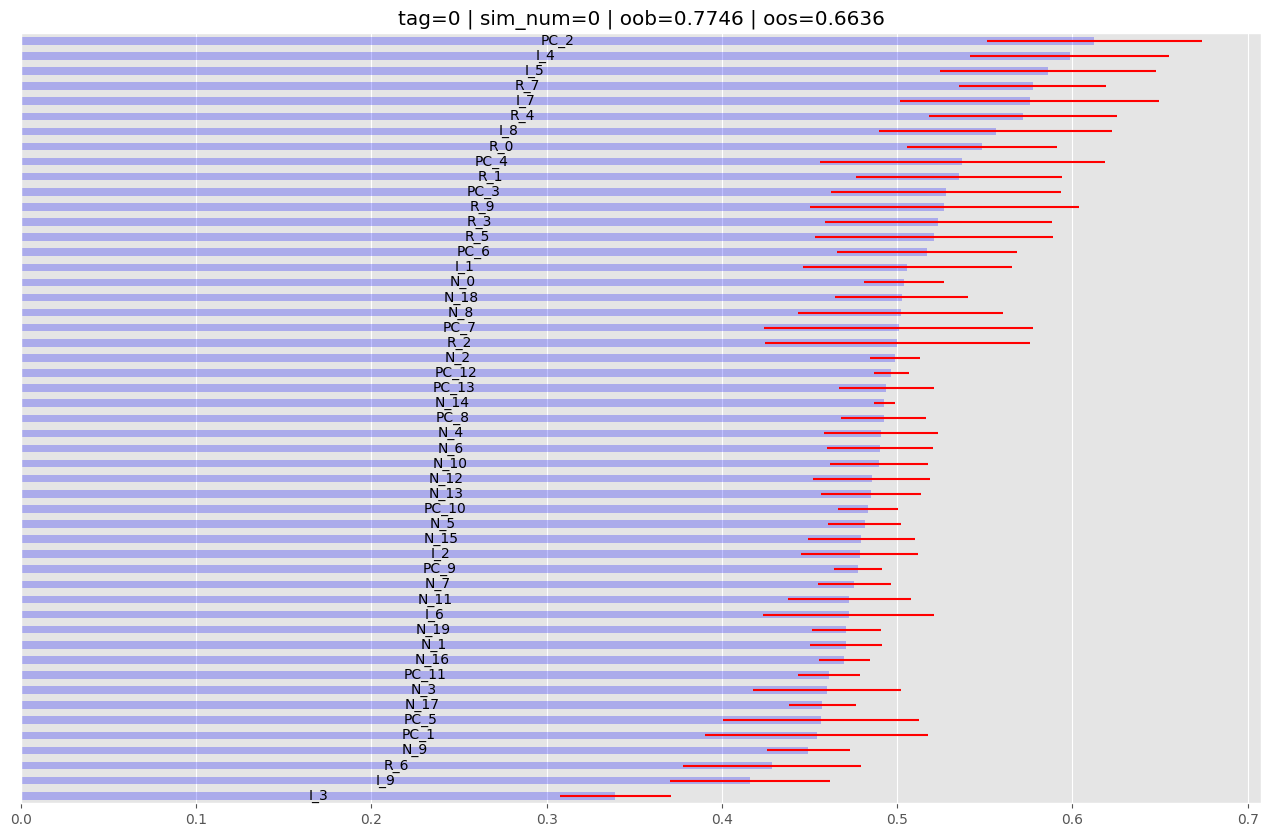

In [16]:
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=5,
    random_state=42,
    class_weight="balanced_subsample",
    n_jobs=-1,
    oob_score=True,
    max_features=int(1) # masking effects
)

run_test(model, dropped_union_train_df, labels_df, cv_n_splits=10, run='', metrics=['MDI', 'MDA', 'SFI'])

### c. Do you appreciate significant changes in the rankings of important  features, relative to the results from exercise 2?

Interestingly, after dropping the most significant labels, the results align with the ones that only fit the principal components. The likely reason is that dropping `R_8` and `I_0` removes the strongest raw-feature proxies, so the model’s remaining signal is dominated by the PCA representation again. The masking effect (`max_features=int(1)`) setting also matters. Each tree split only sees one candidate feature, so dominant raw features cannot always mask the PCs. After dropping `R_8` and `I_0`, this makes it easier for useful PCs like `PC_2` and `PC_6` to receive credit.

## 4. Using the code presented in Section 8.6:

### a. Generate a dataset (X, y) of 1E6 observations, where 5 features are informative, 5 are redundant and 10 are noise.

In [17]:
# To prevent running too long, we set n_samples to 10000
new_trains_df, new_labels_df = get_test_data(n_features=20, n_informative=5, n_redundant=5, n_samples=10000)

### b. Split (X, y) into 10 datasets $\{(X_i, y_i)\}_{i = 1, \dots, 10}$, each of 1E5 observations.

In [18]:
splitted_new_trains_df = [df for _, df in new_trains_df.groupby(np.arange(len(new_trains_df)) // (len(new_trains_df) // 10))]
splitted_new_labels_df = [df for _, df in new_labels_df.groupby(np.arange(len(new_labels_df)) // (len(new_labels_df) // 10))]

In [19]:
print(f"Length of splitted_new_trains_df: {len(splitted_new_trains_df)}")
print(f"with each element of shape: {splitted_new_trains_df[0].shape} and type: {type(splitted_new_trains_df[0])}")

Length of splitted_new_trains_df: 10
with each element of shape: (1000, 20) and type: <class 'pandas.DataFrame'>


### c. Compute the parallelized feature importance (Section 8.5), on each of the  10 datasets, $\{(X_i, y_i)\}_{i = 1, \dots, 10}$.

In [20]:
from concurrent.futures import ThreadPoolExecutor
from sklearn.base import clone


def _run_job(job):
    job = job.copy()
    func = job.pop('func')

    if 'model' in job:
        job['model'] = clone(job['model'])

    return func(**job)


def process_jobs(jobs, num_threads=1):
    if len(jobs) == 0:
        return []

    num_threads = max(1, min(num_threads, len(jobs)))
    if num_threads == 1:
        return [_run_job(job) for job in jobs]

    with ThreadPoolExecutor(max_workers=num_threads) as executor:
        return list(executor.map(_run_job, jobs))


def combine_imps(imps):
    return pd.DataFrame({
        'mean': pd.concat([x['mean'] for x in imps], axis=1).mean(axis=1),
        'std': pd.concat([x['std'] for x in imps], axis=1).mean(axis=1),
    })

def chunked_run_test(X, cont, n_chunks=1, run='', allow_masking=True, metrics=['MDI', 'MDA', 'SFI']):
    chunks = np.array_split(X.index, n_chunks)
    
    model = RandomForestClassifier(
        n_estimators=300,
        max_depth=5,
        random_state=42,
        class_weight="balanced_subsample",
        n_jobs=-1,
        oob_score=True,
        max_features=int(1) if allow_masking else None # control the masking effects
    )
    for metric in metrics:
        jobs = [{
            'func': feature_importance,
            'model': model,
            'X_df': X.loc[chunk],
            'y_df': cont.loc[chunk],
            'metric': metric,
        } for chunk in chunks]

        results = process_jobs(jobs, num_threads=32)
    
        imps, oobs, ooss = zip(*results)

        feature_imp = combine_imps(imps)
        oob_score, oos_score = pd.Series(oobs).mean(), pd.Series(ooss).mean()

        plot_feature_importance(
            feature_imp, oob_score=oob_score, oos_score=oos_score,
            savefig=True, output_path='img/{}_feat_imp{}.png'.format(metric, run)
        )

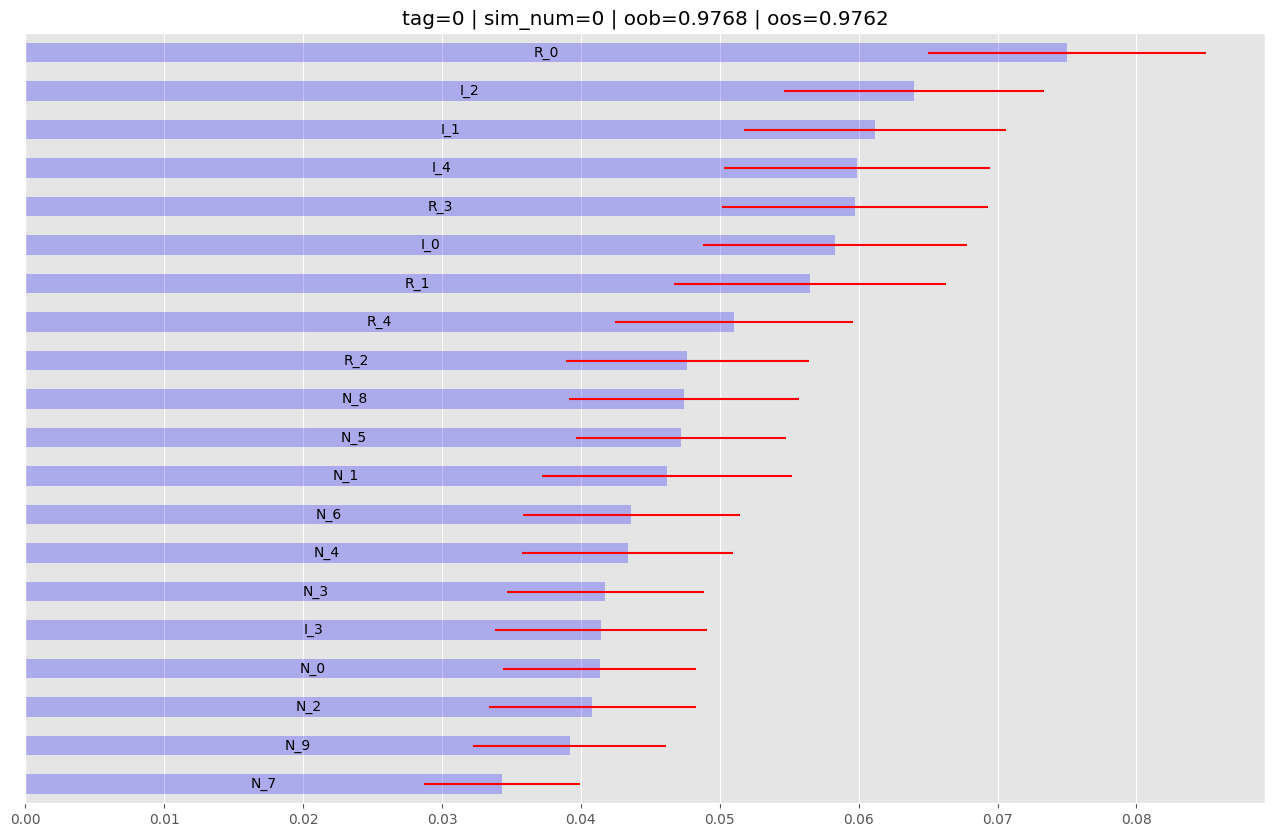

/Users/lucaswychan/advances-in-financial-ml-exercises/.venv/lib/python3.12/site-packages/pandas/core/nanops.py:1027: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/Users/lucaswychan/advances-in-financial-ml-exercises/.venv/lib/python3.12/site-packages/matplotlib/transforms.py:352: RuntimeWarning: invalid value encountered in scalar subtract
  return points[1, 0] - points[0, 0]


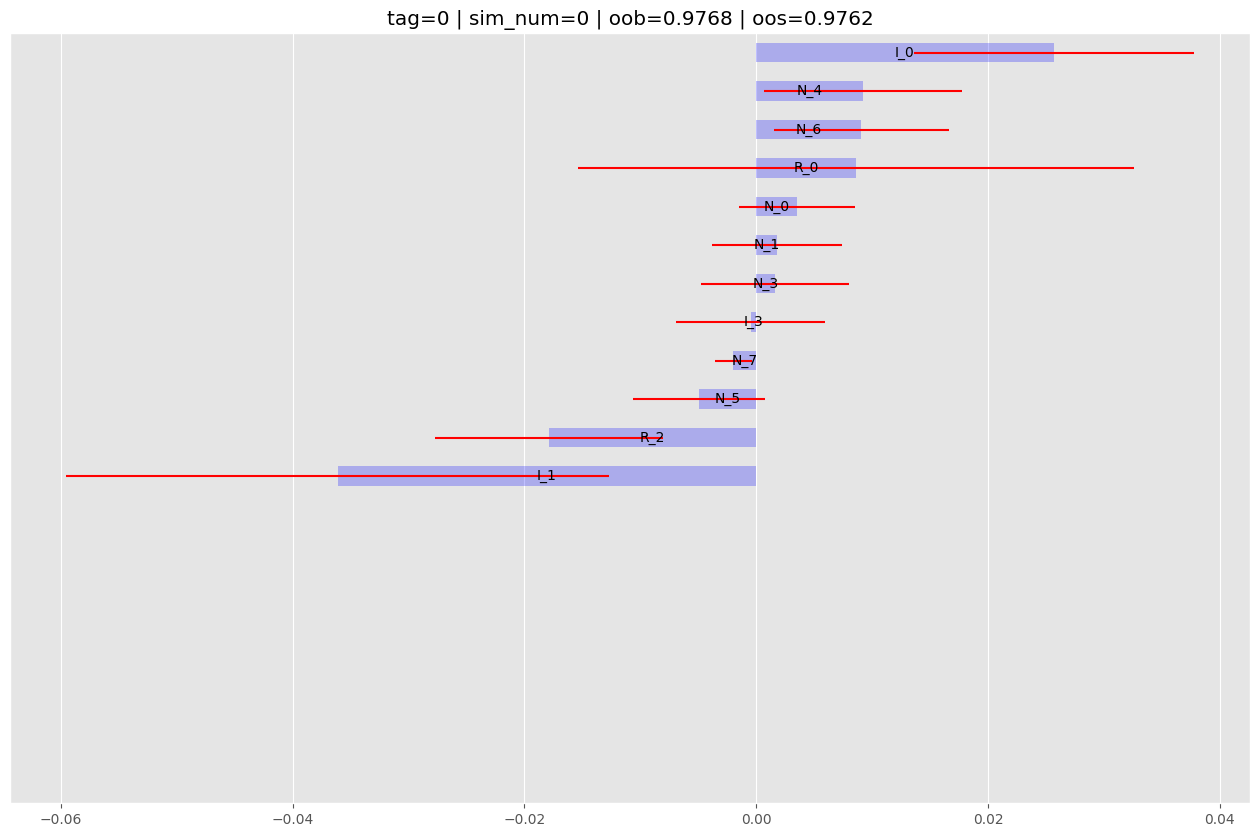

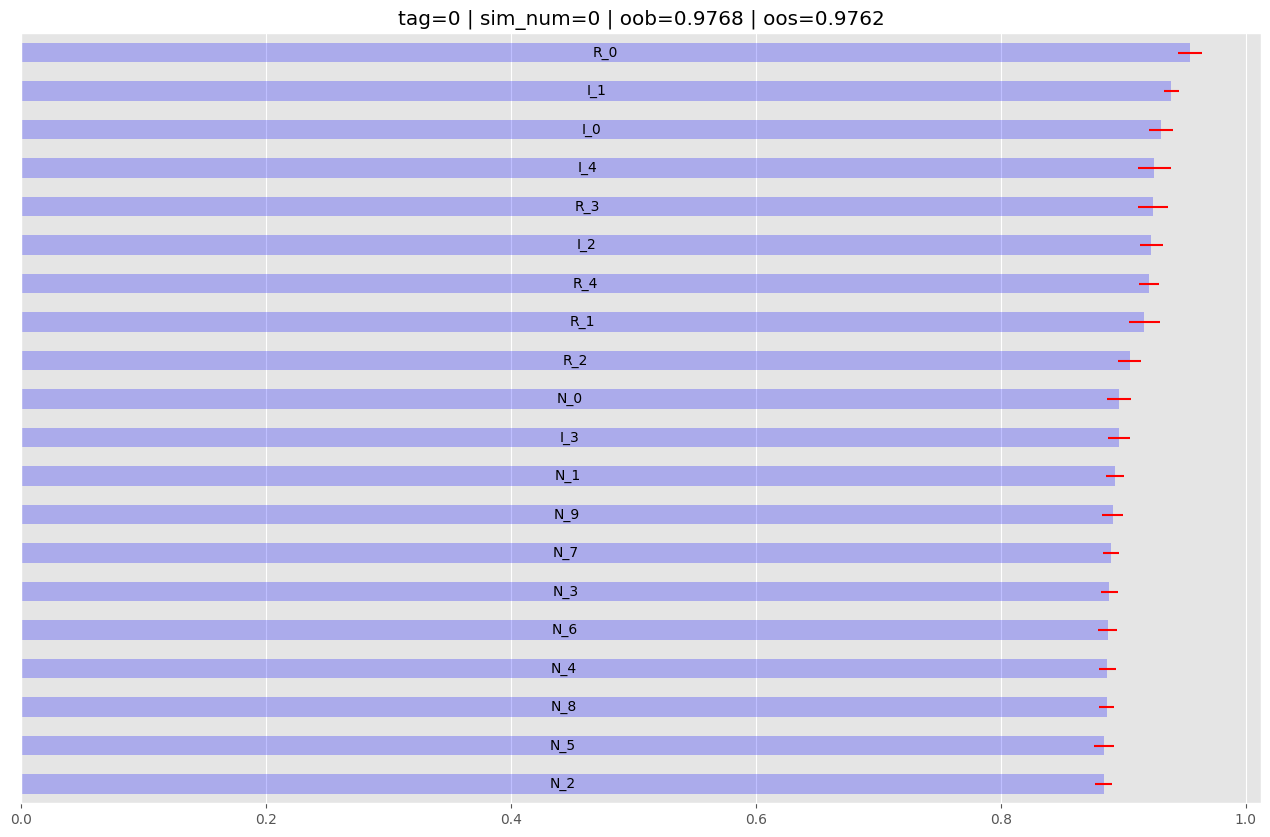

In [21]:
chunked_run_test(new_trains_df, new_labels_df, n_chunks=10, allow_masking=True, metrics=['MDI', 'MDA', 'SFI'])

### d. Compute the stacked feature importance on the combined dataset (X, y).

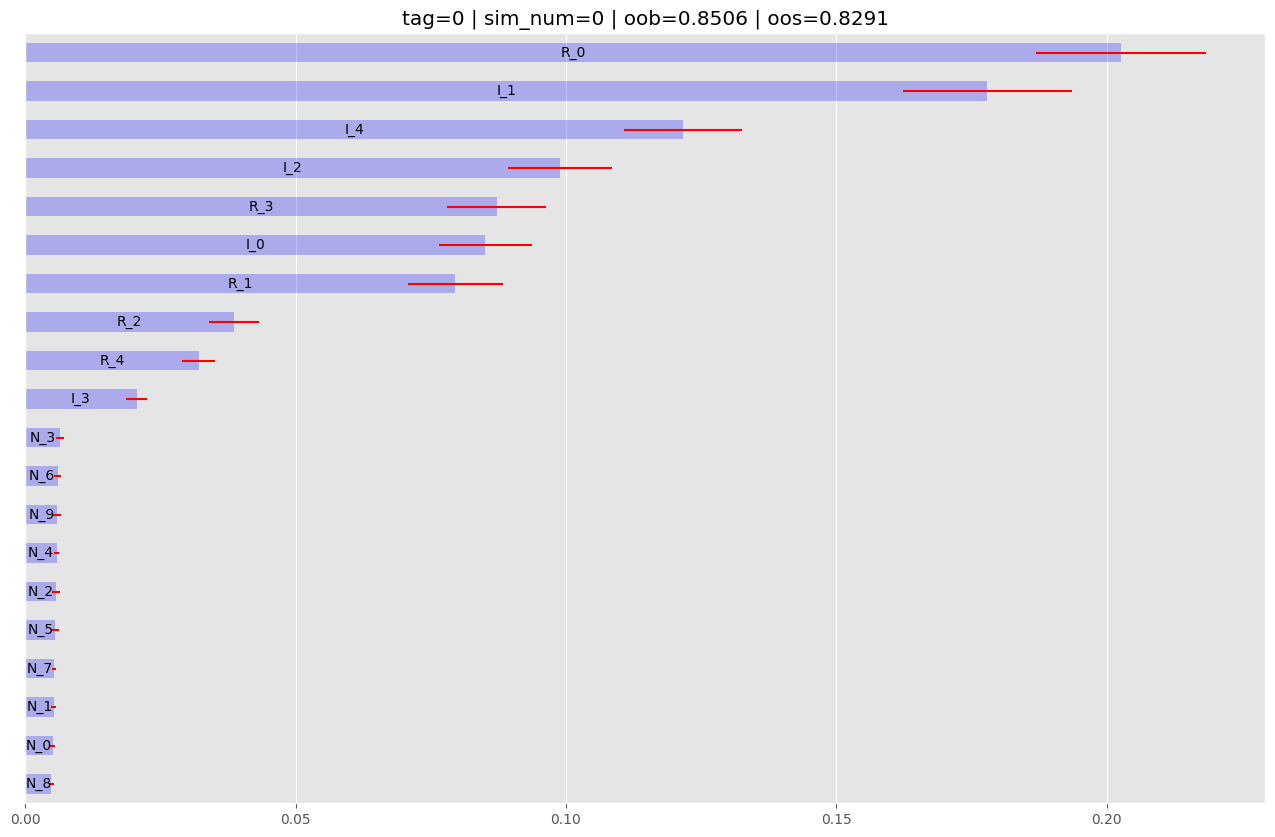

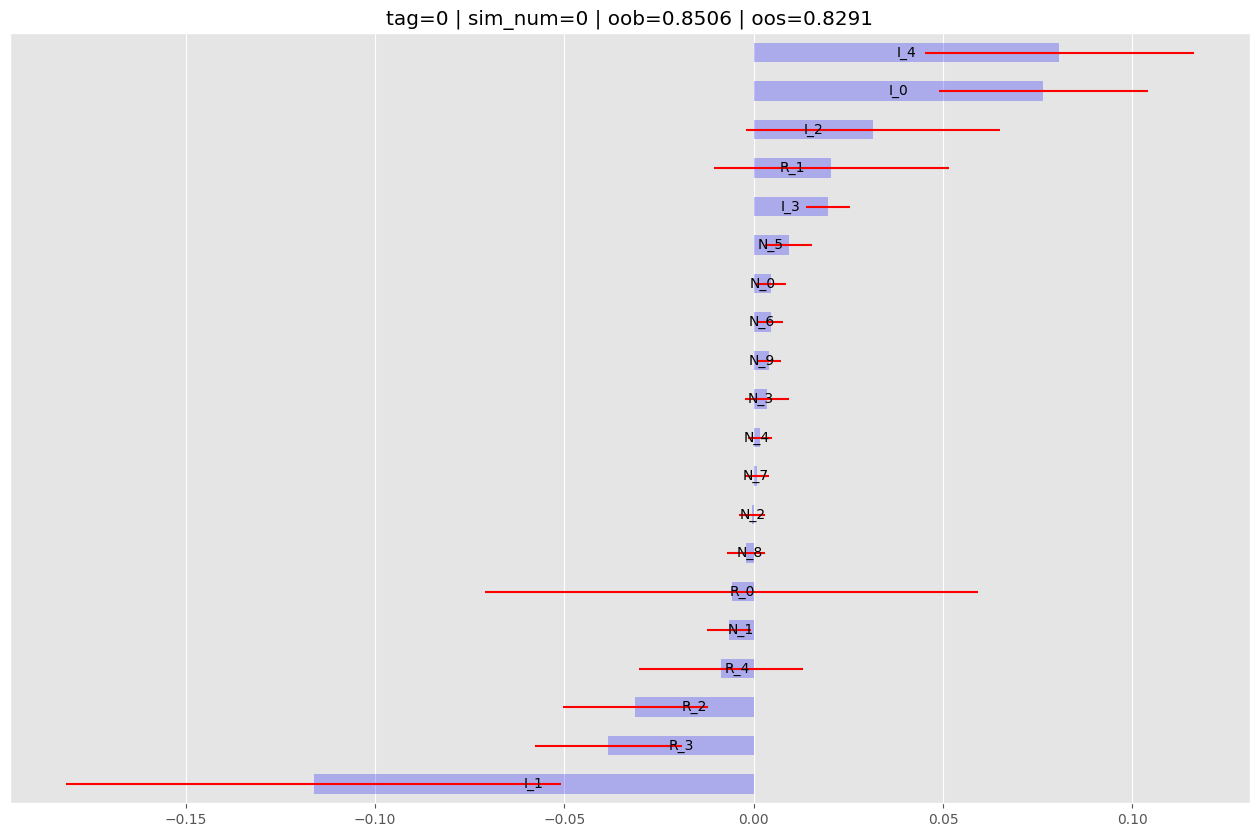

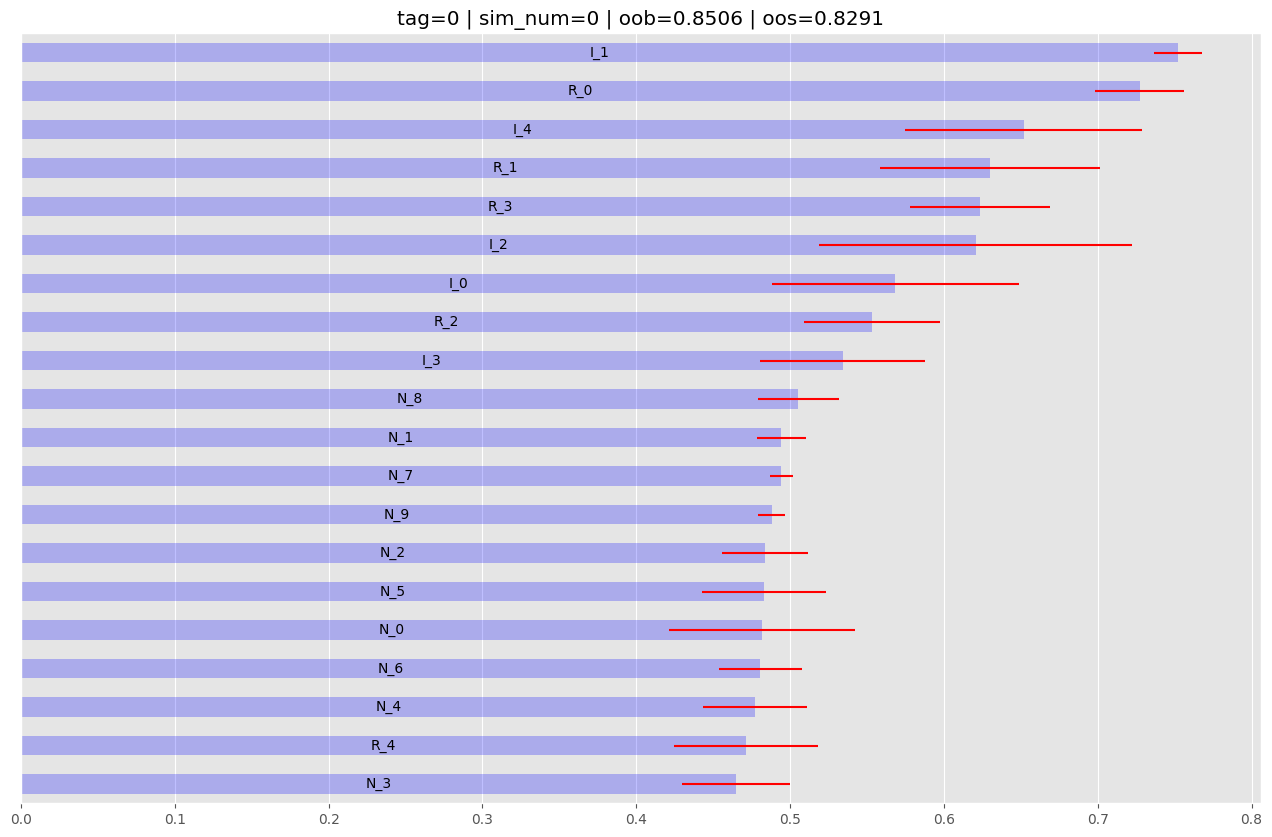

In [22]:
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=5,
    random_state=42,
    class_weight="balanced_subsample",
    n_jobs=-1,
    oob_score=True,
    max_features=int(1) # masking effects
)

run_test(model, new_trains_df, new_labels_df, cv_n_splits=10, run='', metrics=['MDI', 'MDA', 'SFI'])

### e. What causes the discrepancy between the two? Which one is more  reliable?

Although both methods produce similar rankings, the stacked feature importance ranks the noise features lower than that of the parallelized feature importance, which is more reliable.

## 5. Repeat all MDI calculations from exercises 1–4, but this time allow for masking effects. That means, do not set max_features=int(1) in Snippet 8.2. How do results differ as a consequence of this change? Why?

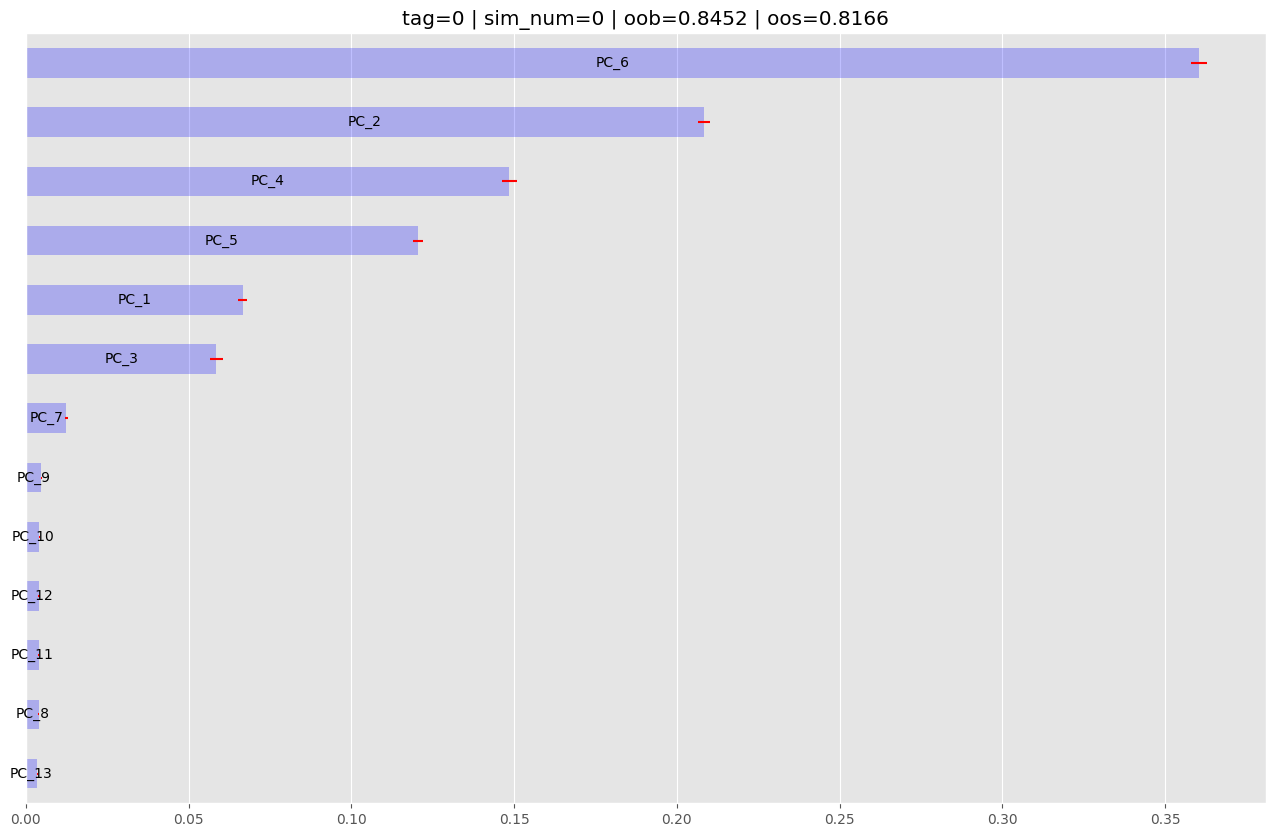

In [25]:
# First fit it on the principal components only

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=5,
    random_state=42,
    class_weight="balanced_subsample",
    n_jobs=-1,
    oob_score=True,
    max_features=None # NO masking effects
)

run_test(model, df_p, labels_df, cv_n_splits=10, run='', metrics=['MDI'])

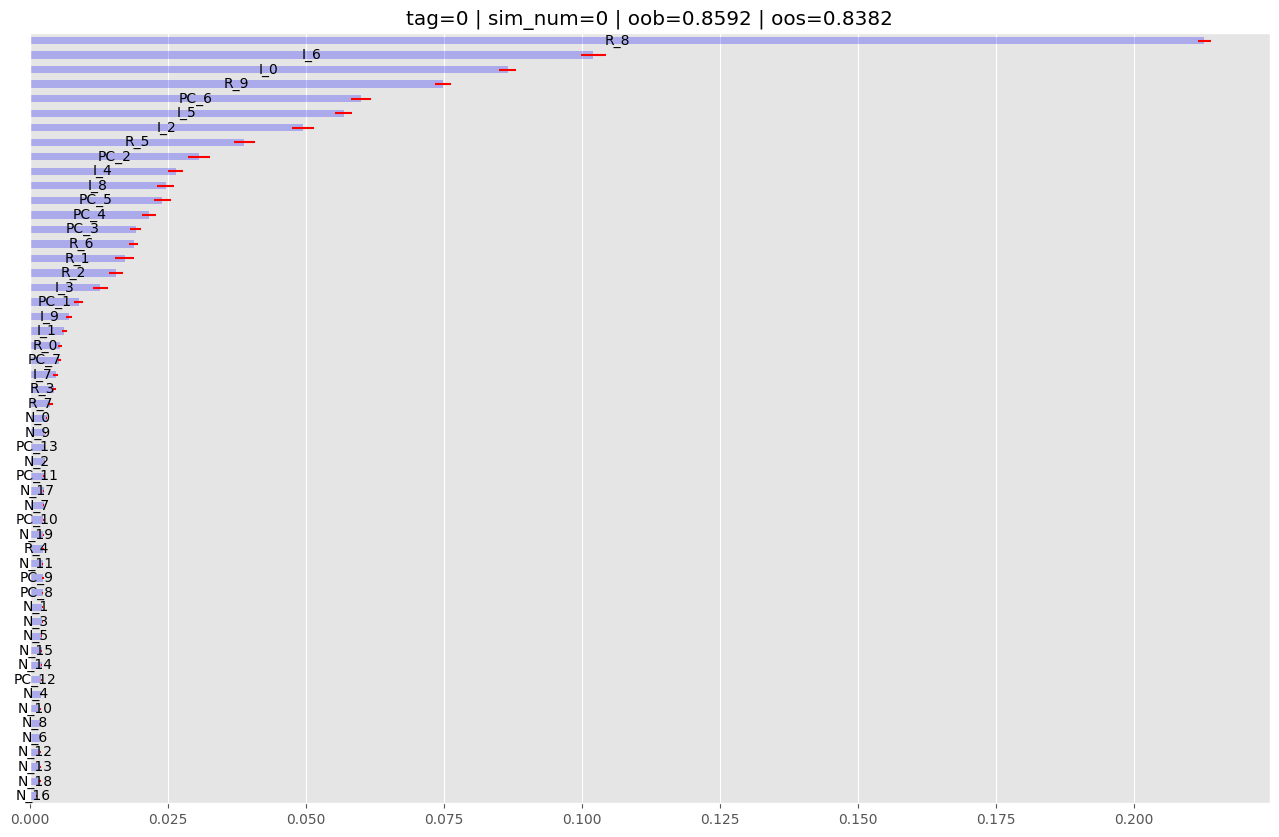

In [26]:
# Second fit it on the union of the principal components and the original features

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=5,
    random_state=42,
    class_weight="balanced_subsample",
    n_jobs=-1,
    oob_score=True,
    max_features=None # NO masking effects
)

run_test(model, union_train_df, labels_df, cv_n_splits=10, run='', metrics=['MDI'])

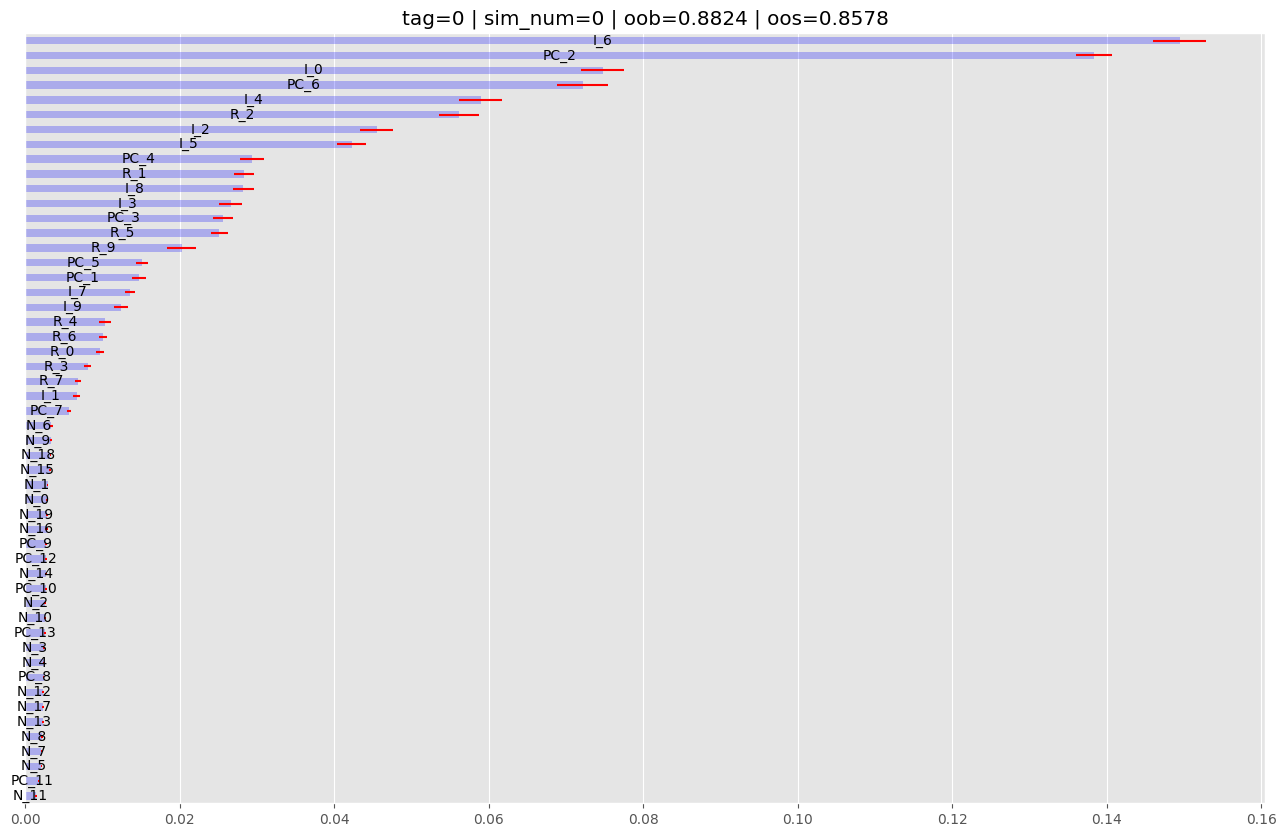

In [28]:
# Third fit it on the union df but with the dropped feature to be the highest rank in the previous run

dropped_union_train_df_for_mdi = union_train_df.drop(columns=['R_8'])

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=5,
    random_state=42,
    class_weight="balanced_subsample",
    n_jobs=-1,
    oob_score=True,
    max_features=None # NO masking effects
)

run_test(model, dropped_union_train_df_for_mdi, labels_df, cv_n_splits=10, run='', metrics=['MDI'])

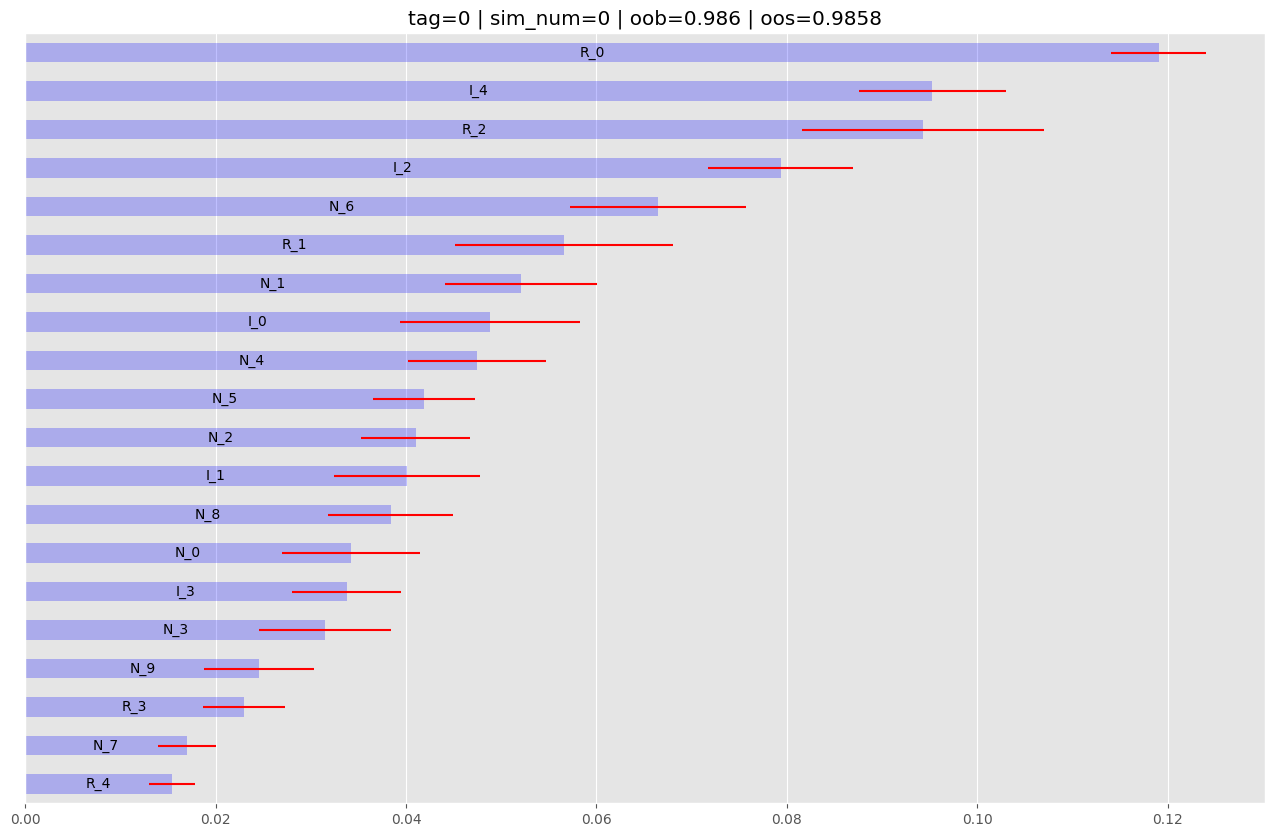

In [29]:
# Fourth run the Parallelized vs. Stacked Feature Importance

chunked_run_test(new_trains_df, new_labels_df, n_chunks=10, allow_masking=False, metrics=['MDI'])

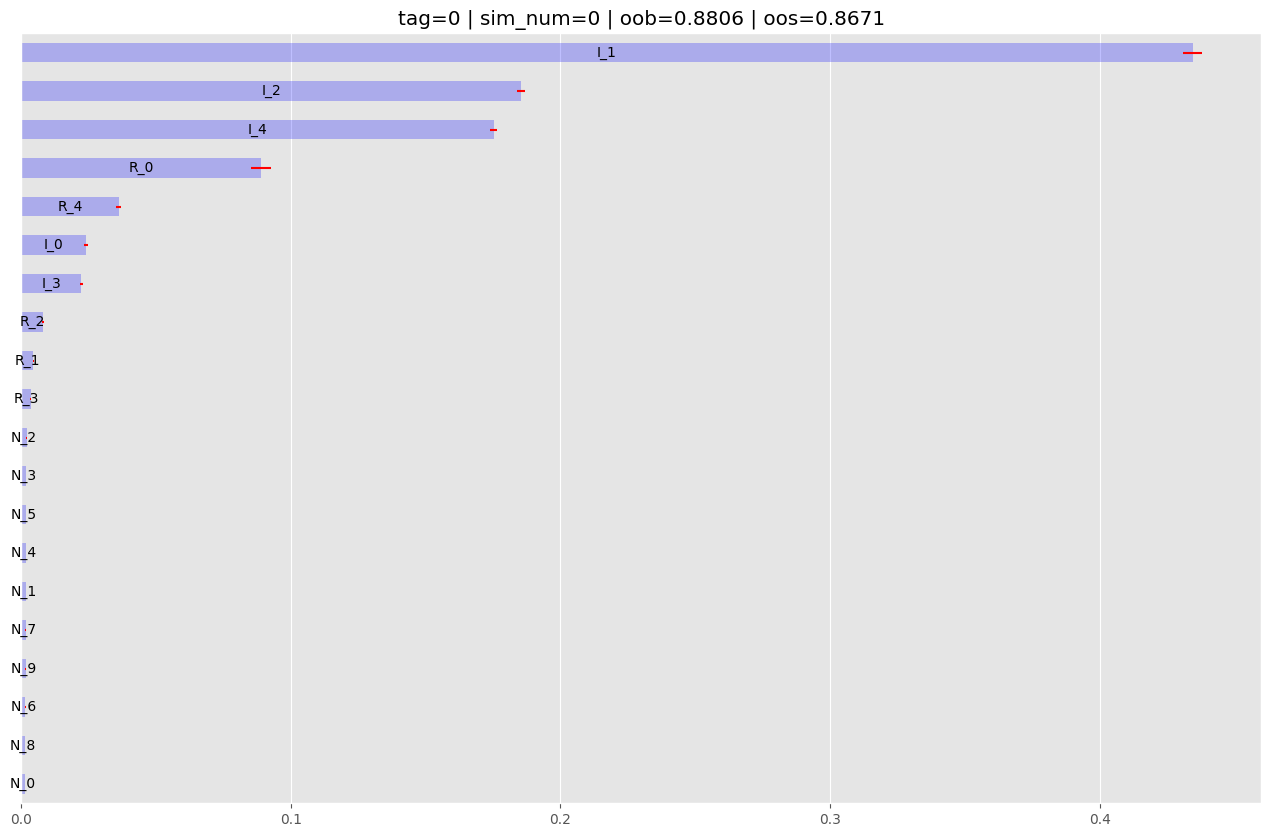

In [30]:
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=5,
    random_state=42,
    class_weight="balanced_subsample",
    n_jobs=-1,
    oob_score=True,
    max_features=None # NO masking effects
)

run_test(model, new_trains_df, new_labels_df, cv_n_splits=10, run='', metrics=['MDI'])

There are few things to notice:

1. The forest without masking effect ranks `PC_6` higher than `PC_2`, which may indicate this PC becomes more useful when trees can choose it in the context of all other PCs. That may indicate nonlinear interaction or conditional usefulness, but MDI alone does not prove interaction. Orthogonality reduces linear masking, so a large rank increase under `max_features=None` is more suggestive of conditional/nonlinear usefulness than it would be among raw correlated features.

2. `R_8` is ranked as the most important feature again even we remove the masking effect.

3. After removing `R_8`, the second important feature in the previous run (the dataframe consisting both original features and the principal components) is now ranked highest, which is not surprising.

4. For the case of parallelized v.s. stacked feature importance, this time the latter one is way more reliable than the former one, as noise features are given so less importance in the latter case, but the former case gives considerable importance to the noise features.